In [ ]:
import numpy as np 
import torch
import pandas as pd
from tqdm import tqdm
from sklearn import metrics
from src.model.data import EnformerDataset
from src.model.net import  DeepBurst
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from src.model.constants import get_config


torch.autograd.set_detect_anomaly(True)

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]


#
# Training setup.
#
    
def evaluation(out:'torch.Tensor', label:'torch.Tensor'):
    score = out.softmax(axis=1)[:, 1]
    pred = out.argmax(axis=1)

    acc = metrics.accuracy_score(label, pred) * 100
    auc = metrics.roc_auc_score(label, score) * 100
    ap = metrics.average_precision_score(label, score) * 100
    return score, label, pred, acc, auc, ap

config_path = "configs/default.yaml"
config = get_config(config_path)


remove_marks = None
if remove_marks:
    config["remove_marks"] = [remove_marks]
else:
    config["remove_marks"] = []

feature_bin_kws = config['feature_bin_kws']
seed = config["seed"]

config['marked_bin_idxes'] = []
config['masked_marks'] = []

bsz = config["bsz"]
gamma = config["gamma"]

i_max = config["i_max"]
w_prom = config["w_prom"]
w_max = config["w_max"]

n_feats_p = config['promoter_feats_basic_nums'] - len(config["remove_marks"])  + feature_bin_kws['out_channels'] if add_feature_bin else config['promoter_feats_basic_nums'] - len(config["remove_marks"])
n_feats_pcres = config['pcres_feats_basic_nums'] 
d_emb = config["embed"]["d_model"]
embed_kws = config["embed"]
pairwise_interaction_kws = config["pairwise_interaction"]
regulation_kws = config["regulation"]
d_head = config["d_head"]
targets = ['bs_label','bf_label']
gene_id = "ENSG00000155660" 
npy_dir = f"extra/datasets/processed/v1/{gene_id}_random_center_replaced_100k/regions"


binsizes = [500]

predictions = []
for eid in ["E003"]:
    for fold in [2]:
        print(f"eid:{eid},fold:{fold}")
        checkpoints = f"checkpoints/{eid}.{fold}.bs_bf_para.model.pt"

        meta_path = f"extra/datasets/processed/v1/{gene_id}_random_center_replaced_100k/meta_data.csv"

        #
        # Setup end.
        #

        seed_everything(seed)
        meta = (
            pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
        )  # load and shuffle.

        # Split genes into two sets (train/val).
        genes = set(meta.gene_id.unique())
        n_genes = len(genes)
        print("Target genes:", len(genes))
        print(f"n_feats_p:{n_feats_p}")

        splits = {
            1: ['chr1', 'chr6', 'chr5', 'chr8', 'chr14', 'chrY'],
            2: ['chr7', 'chr10', 'chr11', 'chr12', 'chr15', 'chr21'],
            3: ['chr2', 'chr3', 'chr4', 'chr16', 'chr18', 'chr20'],
            4: ['chr9', 'chr13', 'chr17', 'chr19', 'chr22', 'chrX'],
        }

        chromosome_splits = {}
        for key, chroms in splits.items():
            for chrom in chroms:
                chromosome_splits[chrom] = key

        qs = [
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 1,axis=1)].gene_id.tolist(),
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 2,axis=1)].gene_id.tolist(),
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 3,axis=1)].gene_id.tolist(),
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 4,axis=1)].gene_id.tolist(),
        ]

        train_genes = (
            qs[(fold + 0) % 4] + qs[(fold + 1) % 4] + qs[(fold + 2) % 4]
        )
        val_genes = qs[(fold + 3) % 4]



        print(len(train_genes), len(val_genes))

        val_dataset = EnformerDataset(meta_path,val_genes,npy_dir, binsizes=[2000, 500, 100])
        val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=bsz)


        model = DeepBurst(
            n_feats_p,
            d_emb,
            d_head,
            embed_kws=embed_kws,
            binsizes=binsizes,
            seed=42,
            targets=targets,
        ).to(DEVICE)

        ckpt = torch.load(checkpoints,map_location=DEVICE)
        model.load_state_dict(ckpt["net"])


eid:E003,fold:2
Target genes: 10000
n_feats_p:7
0 10000


In [12]:

import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault

rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 6 ,
        'axes.titleweight' :'regular',
        
        'figure.titleweight' : 'regular' ,
        'figure.titlesize' : 6 ,
        'figure.labelsize' : 6 ,
        'figure.labelweight' : 'regular' , 
        
        'axes.labelsize' : 6 ,
        'axes.labelpad' : 2 ,
        'axes.labelweight' : 'regular' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'legend.fontsize' : 6 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'black',   
        'legend.edgecolor': 'black',
        'legend.labelcolor': 'black',  # 设置图例标签字体颜色（在新版matplotlib中支持）
        'axes.edgecolor': 'black',
        'axes.labelcolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
        'axes.titlecolor': 'black',
        'axes.labelcolor': 'black',

        'xtick.labelsize': 6,
        'ytick.labelsize': 6,
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        'xtick.major.width': 0.5,  # X轴刻度主刻度线宽度
        'ytick.major.width': 0.5, 
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        'text.color': 'black',  # 全局文字颜色

        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )



sns.set_palette("colorblind")
MARKS = ["H3K4me1","H3K4me3","H3K9me3","H3K27me3","H3K36me3","H3K27ac","H3K9ac"]
color_map = {'H3K4me1':'#A28F19','H3K4me3':'#7FA5D0','H3K9me3':'#FDE4A4','H3K27ac':'#F5B6AC','H3K27me3':'#7CA68B','H3K36me3':'#80448A','H3K9ac':'#C7886D'}




In [4]:
gene_id = 'ENSG00000155660'
strand = '+' # '+', '-' 
results = []
for i in tqdm(range(1,10001)):
    if i < 10:
        i = f'0000{i}'
    elif i < 100:
        i = f'000{i}'
    elif i < 1000:
        i = f'00{i}'
    elif i < 10000:
        i = f'0{i}'
    else:
        i = str(i)
    data = np.load(f'{npy_dir}/ENSGRND000{i}.npy')
    # print(data.shape)

    if strand == '-':
        data = np.flip(data, axis=0)  # 翻转数据

    def bin_40kbp_matrix(matrix: np.ndarray, bin_size_bp: int = 500) -> np.ndarray:
        """
        将 40kbp × tracks 的矩阵，按 bin_size_bp 分箱平均。
        
        参数：
            matrix: np.ndarray, shape=(40000, C)，40kbp 范围的预测结果
            bin_size_bp: int, 每个 bin 的碱基长度，默认 500bp
        
        返回：
            np.ndarray, shape=(N_bins, C)，N_bins = 40000/bin_size_bp
        """
        length, C = matrix.shape
        assert length == 40000, f"输入长度应为40kbp，这里是 {length}"
        
        n_bins = length // bin_size_bp  # 80
        binned = matrix.reshape(n_bins, bin_size_bp, C).mean(axis=1)
        return binned

    binned = bin_40kbp_matrix(data)
    binned = torch.tensor(binned[np.newaxis, np.newaxis,:,:]).to(DEVICE) 
    model.eval()
    with torch.no_grad():
        out = model(binned)
        val_preds = {}

    for target, pred in zip(targets,torch.chunk(out, len(targets), axis=-1)):
                val_preds[target] = pred

    line = [f'ENSGRND000{i}']
    for target in targets:
        val_score = val_preds[target].softmax(axis=1)[:, 1]
        line.append(val_score.cpu().numpy().tolist()[0])

    results.append(line)

df = pd.DataFrame(results, columns=['id'] + targets)

df.columns = ['simulation_id'] + [f'{target}_score' for target in targets]
df.to_csv(f'extra/results/{gene_id}_random_center_replaced_100k.csv', index=False)


100%|██████████| 10000/10000 [00:48<00:00, 204.58it/s]


In [4]:

def bin_40kbp_matrix(matrix: np.ndarray, bin_size_bp: int = 500) -> np.ndarray:
    """
    将 40kbp × tracks 的矩阵，按 bin_size_bp 分箱平均。
    
    参数：
        matrix: np.ndarray, shape=(40000, C)，40kbp 范围的预测结果
        bin_size_bp: int, 每个 bin 的碱基长度，默认 500bp
    
    返回：
        np.ndarray, shape=(N_bins, C)，N_bins = 40000/bin_size_bp
    """
    length, C = matrix.shape
    assert length == 40000, f"输入长度应为40kbp，这里是 {length}"
    
    n_bins = length // bin_size_bp  # 80
    binned = matrix.reshape(n_bins, bin_size_bp, C).mean(axis=1)
    return binned


# 7 个 histone track 的名字（保持保存时的顺序）

def plot_tracks(tracks, ylim=None, is_binned=True,color_map = None,legend_order=None, figsize = (8/2.54, 3.5/2.54),legend = False,saved_path = None):
    """
    绘制多个组蛋白修饰的轨迹。

    参数：
        tracks (np.ndarray): 形状为 (N_bins, N_tracks) 的矩阵
        track_names (list): 轨迹名称列表
    """
    track_names = [
    'H3K4me1',
    'H3K4me3',
    'H3K9me3',
    'H3K27me3',
    'H3K36me3',
    'H3K27ac',
    'H3K9ac'
    ]
    if is_binned:
        tracks = bin_40kbp_matrix(tracks)
    # 横轴坐标：-20kb 到 +20kb
    x = (np.arange(tracks.shape[0]) - (tracks.shape[0] // 2 + 1)) * 500


    plt.figure(figsize=figsize)
    for i, name in enumerate(track_names):
        color = color_map[name] if color_map else None
        if color:
            plt.plot(x, tracks[:, i], label=name, lw=0.3, color=color)
        else:
            # 如果没有提供颜色，则使用默认颜色
            plt.plot(x, tracks[:, i], label=name, lw=0.3)

    plt.axvline(0, color='grey', linestyle='--', lw=0.5, label="TSS")

    if ylim:
       plt.ylim(top=ylim)
    plt.xlabel("Position relative to TSS (kbp)")
    plt.ylabel("Signal intensity\n(Enformer prediction)")
    handles, labels = plt.gca().get_legend_handles_labels()
    if legend_order:
        # 按 legend_order 重新排序
        order_dict = {name: i for i, name in enumerate(legend_order)}
        sorted_items = sorted(zip(handles, labels), key=lambda x: order_dict.get(x[1], 1e9))
        handles, labels = zip(*sorted_items)

    if legend:
        plt.legend(
            handles,
            labels,
            bbox_to_anchor=(1.1, 1.05),
            loc='upper left',
            fontsize=5
        )
    else:
        plt.legend().remove()
    plt.tight_layout()
    plt.xticks([-20000, 0, 20000], ['-20', '0', '20'])

    if saved_path:
        plt.savefig(saved_path, format='eps', bbox_inches='tight')
    plt.show()




# High expression

In [5]:
df = pd.read_csv('extra/results/ENSG00000155660_random_center_replaced_100k.csv')


In [6]:
df[(df['bs_label_score']>0.5) & (df['bf_label_score']<0.5)][:50]

,simulation_id,bs_label_score,bf_label_score
228,ENSGRND00000229,0.504364,0.393757
505,ENSGRND00000506,0.618555,0.447454
563,ENSGRND00000564,0.509178,0.394102
1567,ENSGRND00001568,0.564072,0.496789
2088,ENSGRND00002089,0.516115,0.399182
2637,ENSGRND00002638,0.656809,0.428199
3710,ENSGRND00003711,0.513393,0.340928
4378,ENSGRND00004379,0.515823,0.473432
4719,ENSGRND00004720,0.535442,0.479901
5073,ENSGRND00005074,0.644372,0.459186


/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/seaborn/axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  f.tight_layout()
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_2402/3880544862.py:94: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  g.figure.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


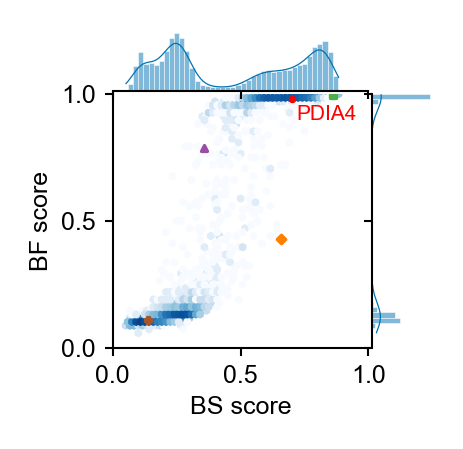

In [7]:
# ===== Joint hexbin + hist (kde=True) marginals =====
# 依赖：df 至少包含 'bs_label_score'（x）与 'bf_label_score'（y）

# -------- 可调参数 --------
GRIDSIZE   = 60
ALPHA_SCAT = 0.25
N_SCAT     = 2000
BINS       = 'log'       # hexbin 计数对数缩放
CMAP       = 'Blues'
BW         = 0.8         # KDE 平滑带宽（传给 histplot 的 kde_kws）
NBINS_MARG = 50          # 边际直方图分箱
FIG_CM     = 3.5
XCOL, YCOL = 'bs_label_score', 'bf_label_score'

# -------- JointGrid：主图 hexbin --------
g = sns.JointGrid(
    data=df, x=XCOL, y=YCOL,
    height=FIG_CM/2.54, ratio=4, space=0.05,
    xlim=(0, 1), ylim=(0, 1)
)

hb = g.ax_joint.hexbin(
    df[XCOL], df[YCOL],
    gridsize=GRIDSIZE, mincnt=1, bins=BINS,
    extent=(0, 1, 0, 1), cmap=CMAP
)



# -------- 边际：histplot + KDE（限制到 [0,1]）--------
sns.histplot(
    data=df, x=XCOL, ax=g.ax_marg_x,
    bins=NBINS_MARG, binrange=(0, 1),
    stat='density', element='bars', fill=True,
    kde=True, 
    kde_kws=dict(bw_adjust=BW,)
)
sns.histplot(
    data=df, y=YCOL, ax=g.ax_marg_y,
    bins=NBINS_MARG, binrange=(0, 1),
    stat='density', element='bars', fill=True,
    kde=True,
    kde_kws=dict(bw_adjust=BW, clip=(0, 1), cut=0,)
)
g.ax_marg_x.set_xlim(0, 1)
g.ax_marg_y.set_ylim(0, 1)
g.ax_marg_x.lines[-1].set_linewidth(0.3)    # 调粗 KDE 曲线
g.ax_marg_y.lines[-1].set_linewidth(0.3)    # 调粗 KDE 曲线

# -------- 轴与刻度 --------
g.ax_joint.set_xlabel('BS score', fontsize=6)
g.ax_joint.set_ylabel('BF score', fontsize=6)
g.ax_joint.set_xticks([0, 0.5, 1.0])
g.ax_joint.set_yticks([0, 0.5, 1.0])
# for ax in [g.ax_joint, g.ax_marg_x, g.ax_marg_y]:
#     ax.tick_params(labelsize=6)

# -------- 标注 PDIA4 --------
x0, y0 = 0.7, 0.98
g.ax_joint.scatter(x0, y0, color="red", s=1, zorder=5)  # 标红点
g.ax_joint.annotate(
    "PDIA4", 
    (x0, y0), 
    textcoords="offset points", 
    xytext=(1, -5),  # 注释位置相对偏移
    fontsize=5, 
    color="red"
)

# -------- 可选：标注若干 simulation_id --------
def _get_loc(simulation_id: str):
    row = df[df['simulation_id'] == simulation_id]
    if row.empty:
        return None
    return float(row.iloc[0][XCOL]), float(row.iloc[0][YCOL])

markers = ['s','^','D','P','X','*']
colors  = ["#4DAF4A", "#984EA3", "#FF7F00", "#A65628", "#F781BF", "#377EB8"]
simulation_ids = ['ENSGRND00003522','ENSGRND00001485','ENSGRND00002638','ENSGRND00001752']

for idx, simulation_id in enumerate(simulation_ids):
    loc = _get_loc(simulation_id)
    if loc:
        x0, y0 = loc
        g.ax_joint.scatter(
            x0, y0, 
            color=colors[idx % len(markers)], 
            s=2,                     # 放大一点更清楚
            zorder=10, 
            marker=markers[idx % len(markers)]  # 不同点不同形状
        )

# -------- 布局与保存 --------
g.figure.tight_layout()
saved_path = 'extra/figures/v6/Figure5G.eps'
g.figure.savefig(saved_path, format='eps', bbox_inches='tight', dpi=300)

plt.show()

## Sample Distribution

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


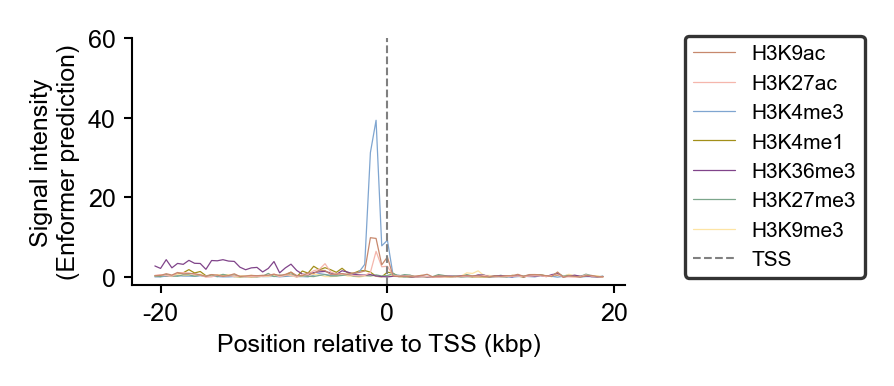

In [9]:
legend_order = ['H3K9ac','H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
tracks = np.load('extra/datasets/processed/v1/E003/regions/ENSG00000155660.npy')[:7].T # (80, 7)
saved_path = 'extra/figures/v6/Figure5F.eps'

plot_tracks(tracks,ylim=60,color_map=color_map,legend_order=legend_order,legend=True,saved_path=saved_path)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


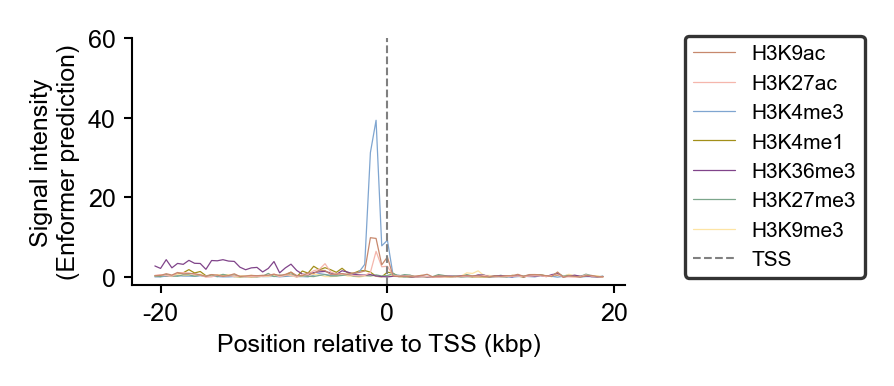

In [11]:
legend_order = ['H3K9ac','H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
tracks = np.load('extra/datasets/processed/v1/E003/regions/ENSG00000155660.npy')[:7].T # (80, 7)
saved_path = 'extra/figures/v6/Figure5F.eps'

plot_tracks(tracks,ylim=60,color_map=color_map,legend_order=legend_order,legend=True,saved_path=saved_path)

        simulation_id  bs_label_score  bf_label_score
3521  ENSGRND00003522        0.859561          0.9965


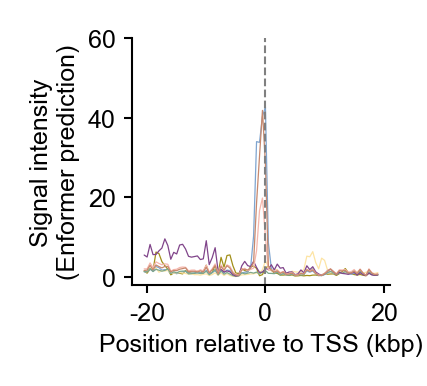

In [12]:
simulation_id = 'ENSGRND00003522'
print(df[df['simulation_id'] == simulation_id])
tracks = np.load(f'{npy_dir}/{simulation_id}.npy') # (80, 7)
saved_path = 'extra/figures/v6/Figure5I_1.eps'
figsize = (4/2.54, 3.5/2.54)
plot_tracks(tracks,ylim=60,color_map=color_map,legend_order=legend_order,figsize=figsize,saved_path=saved_path)


        simulation_id  bs_label_score  bf_label_score
1484  ENSGRND00001485        0.356568         0.78812


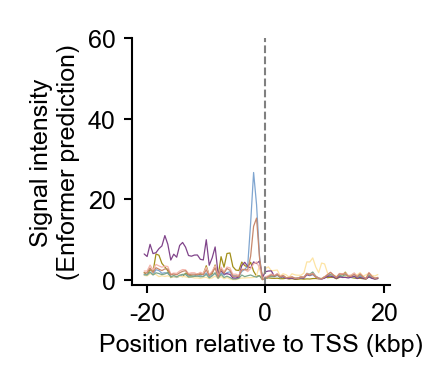

In [ ]:

simulation_id = 'ENSGRND00001485'
print(df[df['simulation_id'] == simulation_id])
tracks = np.load(f'{npy_dir}/{simulation_id}.npy') # (80, 7)
saved_path = 'extra/figures/v6/Figure5F_2.eps'
figsize = (4/2.54, 3.5/2.54)
plot_tracks(tracks,ylim=60,color_map=color_map,legend_order=legend_order,figsize=figsize,saved_path=saved_path)

        simulation_id  bs_label_score  bf_label_score
2637  ENSGRND00002638        0.656809        0.428199


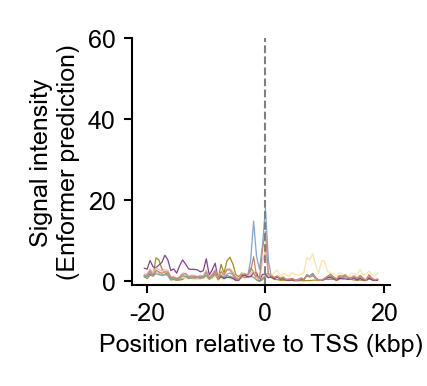

In [10]:
simulation_id = 'ENSGRND00002638'
print(df[df['simulation_id'] == simulation_id])
tracks = np.load(f'{npy_dir}/{simulation_id}.npy') # (80, 7)
saved_path = 'extra/figures/v6/Figure5F_3.eps'
figsize = (4/2.54, 3.5/2.54)
plot_tracks(tracks,ylim=60,color_map=color_map,legend_order=legend_order,figsize=figsize,saved_path=saved_path)

        simulation_id  bs_label_score  bf_label_score
1751  ENSGRND00001752        0.109931        0.195685


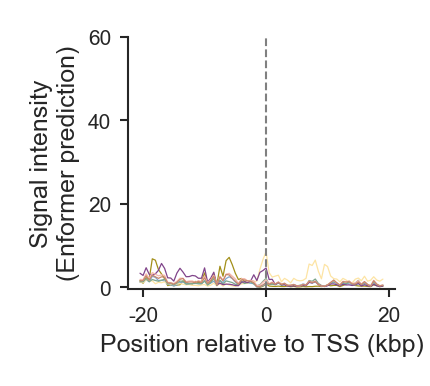

In [ ]:
simulation_id = 'ENSGRND00001752'
print(df[df['simulation_id'] == simulation_id])
tracks = np.load(f'{npy_dir}/{simulation_id}.npy') # (80, 7)
saved_path = 'extra/figures/v6/Figure5F_4.eps'
figsize = (4/2.54, 3.5/2.54)
plot_tracks(tracks,ylim=60,color_map=color_map,legend_order=legend_order,figsize=figsize,saved_path=saved_path)

# Low expression
## FAM163A

In [ ]:
import numpy as np 
import torch
import pandas as pd
from tqdm import tqdm
from sklearn import metrics
from src.model.data import EnformerDataset
from src.model.net import  DeepBurst
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from src.model.constants import get_config


torch.autograd.set_detect_anomaly(True)

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]


#
# Training setup.
#
    
def evaluation(out:'torch.Tensor', label:'torch.Tensor'):
    score = out.softmax(axis=1)[:, 1]
    pred = out.argmax(axis=1)

    acc = metrics.accuracy_score(label, pred) * 100
    auc = metrics.roc_auc_score(label, score) * 100
    ap = metrics.average_precision_score(label, score) * 100
    return score, label, pred, acc, auc, ap

config_path = "configs/default.yaml"
config = get_config(config_path)


remove_marks = None
if remove_marks:
    config["remove_marks"] = [remove_marks]
else:
    config["remove_marks"] = []

feature_bin_kws = config['feature_bin_kws']
seed = config["seed"]

config['marked_bin_idxes'] = []
config['masked_marks'] = []

bsz = config["bsz"]
gamma = config["gamma"]

i_max = config["i_max"]
w_prom = config["w_prom"]
w_max = config["w_max"]

n_feats_p = config['promoter_feats_basic_nums'] - len(config["remove_marks"])  + feature_bin_kws['out_channels'] if add_feature_bin else config['promoter_feats_basic_nums'] - len(config["remove_marks"])
n_feats_pcres = config['pcres_feats_basic_nums'] 
d_emb = config["embed"]["d_model"]
embed_kws = config["embed"]
pairwise_interaction_kws = config["pairwise_interaction"]
regulation_kws = config["regulation"]
d_head = config["d_head"]
targets = ['bs_label','bf_label']
gene_id = "ENSG00000143340" 
npy_dir = f"extra/datasets/processed/v1/{gene_id}_random_center_replaced_100k/regions"


binsizes = [500]

predictions = []
for eid in ["E003"]:
    for fold in [2]:
        print(f"eid:{eid},fold:{fold}")
        checkpoints = f"checkpoints/{eid}.{fold}.bs_bf_para.model.pt"

        meta_path = f"extra/datasets/processed/v1/{gene_id}_random_center_replaced_100k/meta_data.csv"

        #
        # Setup end.
        #

        seed_everything(seed)
        meta = (
            pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
        )  # load and shuffle.

        # Split genes into two sets (train/val).
        genes = set(meta.gene_id.unique())
        n_genes = len(genes)
        print("Target genes:", len(genes))
        print(f"n_feats_p:{n_feats_p}")

        splits = {
            1: ['chr1', 'chr6', 'chr5', 'chr8', 'chr14', 'chrY'],
            2: ['chr7', 'chr10', 'chr11', 'chr12', 'chr15', 'chr21'],
            3: ['chr2', 'chr3', 'chr4', 'chr16', 'chr18', 'chr20'],
            4: ['chr9', 'chr13', 'chr17', 'chr19', 'chr22', 'chrX'],
        }

        chromosome_splits = {}
        for key, chroms in splits.items():
            for chrom in chroms:
                chromosome_splits[chrom] = key

        qs = [
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 1,axis=1)].gene_id.tolist(),
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 2,axis=1)].gene_id.tolist(),
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 3,axis=1)].gene_id.tolist(),
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 4,axis=1)].gene_id.tolist(),
        ]

        train_genes = (
            qs[(fold + 0) % 4] + qs[(fold + 1) % 4] + qs[(fold + 2) % 4]
        )
        val_genes = qs[(fold + 3) % 4]



        print(len(train_genes), len(val_genes))

        val_dataset = EnformerDataset(meta_path,val_genes,npy_dir, binsizes=[2000, 500, 100])
        val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=bsz)


        model = DeepBurst(
            n_feats_p,
            d_emb,
            d_head,
            embed_kws=embed_kws,
            binsizes=binsizes,
            seed=42,
            targets=targets,
        ).to(DEVICE)

        ckpt = torch.load(checkpoints,map_location=DEVICE)
        model.load_state_dict(ckpt["net"])


eid:E003,fold:2
Target genes: 10000
n_feats_p:7
10000 0


In [24]:
gene_id = 'ENSG00000143340'
strand = '+' # '+', '-' 
results = []
for i in tqdm(range(1,10001)):
    if i < 10:
        i = f'0000{i}'
    elif i < 100:
        i = f'000{i}'
    elif i < 1000:
        i = f'00{i}'
    elif i < 10000:
        i = f'0{i}'
    else:
        i = str(i)
    data = np.load(f'{npy_dir}/ENSGRND000{i}.npy')
    # print(data.shape)

    if strand == '-':
        data = np.flip(data, axis=0)  # 翻转数据

    def bin_40kbp_matrix(matrix: np.ndarray, bin_size_bp: int = 500) -> np.ndarray:
        """
        将 40kbp × tracks 的矩阵，按 bin_size_bp 分箱平均。
        
        参数：
            matrix: np.ndarray, shape=(40000, C)，40kbp 范围的预测结果
            bin_size_bp: int, 每个 bin 的碱基长度，默认 500bp
        
        返回：
            np.ndarray, shape=(N_bins, C)，N_bins = 40000/bin_size_bp
        """
        length, C = matrix.shape
        assert length == 40000, f"输入长度应为40kbp，这里是 {length}"
        
        n_bins = length // bin_size_bp  # 80
        binned = matrix.reshape(n_bins, bin_size_bp, C).mean(axis=1)
        return binned

    binned = bin_40kbp_matrix(data)
    binned = torch.tensor(binned[np.newaxis, np.newaxis,:,:]).to(DEVICE) 
    model.eval()
    with torch.no_grad():
        out = model(binned)
        val_preds = {}

    for target, pred in zip(targets,torch.chunk(out, len(targets), axis=-1)):
                val_preds[target] = pred

    line = [f'ENSGRND000{i}']
    for target in targets:
        val_score = val_preds[target].softmax(axis=1)[:, 1]
        line.append(val_score.cpu().numpy().tolist()[0])

    results.append(line)

df = pd.DataFrame(results, columns=['id'] + targets)

df.columns = ['simulation_id'] + [f'{target}_score' for target in targets]
df.to_csv(f'extra/results/{gene_id}_random_center_replaced_100k.csv', index=False)


100%|██████████| 10000/10000 [00:46<00:00, 213.47it/s]


In [16]:
df = pd.read_csv('extra/results/ENSG00000143340_random_center_replaced_100k.csv')
df[(df['bs_label_score']>0.8) & (df['bf_label_score']>0.5)][:50]

,simulation_id,bs_label_score,bf_label_score
77,ENSGRND00000078,0.810723,0.906796
135,ENSGRND00000136,0.807346,0.941875
358,ENSGRND00000359,0.804156,0.939220
513,ENSGRND00000514,0.806637,0.914103
549,ENSGRND00000550,0.801905,0.975159
900,ENSGRND00000901,0.813256,0.958010
1013,ENSGRND00001014,0.814707,0.901804
1090,ENSGRND00001091,0.845199,0.989150
1275,ENSGRND00001276,0.816299,0.914909
1488,ENSGRND00001489,0.825190,0.975918


/Users/wanghan/miniforge3/envs/burstformer/lib/python3.10/site-packages/seaborn/axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  f.tight_layout()
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_2402/192951493.py:108: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  g.figure.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


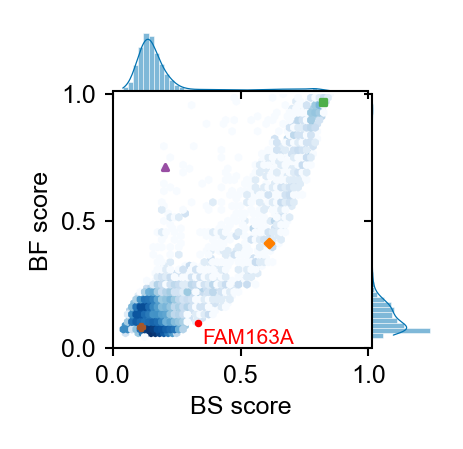

In [17]:
# ===== Joint hexbin + hist (kde=True) marginals =====
# 依赖：df 至少包含 'bs_label_score'（x）与 'bf_label_score'（y）

# -------- 可调参数 --------
GRIDSIZE   = 60
ALPHA_SCAT = 0.25
N_SCAT     = 2000
BINS       = 'log'       # hexbin 计数对数缩放
CMAP       = 'Blues'
BW         = 0.8         # KDE 平滑带宽（传给 histplot 的 kde_kws）
NBINS_MARG = 50          # 边际直方图分箱
FIG_CM     = 3.5
XCOL, YCOL = 'bs_label_score', 'bf_label_score'

# -------- JointGrid：主图 hexbin --------
g = sns.JointGrid(
    data=df, x=XCOL, y=YCOL,
    height=FIG_CM/2.54, ratio=4, space=0.05,
    xlim=(0, 1), ylim=(0, 1)
)

hb = g.ax_joint.hexbin(
    df[XCOL], df[YCOL],
    gridsize=GRIDSIZE, mincnt=1, bins=BINS,
    extent=(0, 1, 0, 1), cmap=CMAP
)

# 可选叠加少量散点
# if N_SCAT and N_SCAT > 0:
#     dsub = df.sample(n=min(N_SCAT, len(df)), random_state=0)
#     g.ax_joint.scatter(dsub[XCOL], dsub[YCOL], s=1, alpha=ALPHA_SCAT, lw=0, color='k')

# -------- 边际：histplot + KDE（限制到 [0,1]）--------
sns.histplot(
    data=df, x=XCOL, ax=g.ax_marg_x,
    bins=NBINS_MARG, binrange=(0, 1),
    stat='density', element='bars', fill=True,
    kde=True, 
    kde_kws=dict(bw_adjust=BW,)
)
sns.histplot(
    data=df, y=YCOL, ax=g.ax_marg_y,
    bins=NBINS_MARG, binrange=(0, 1),
    stat='density', element='bars', fill=True,
    kde=True,
    kde_kws=dict(bw_adjust=BW, clip=(0, 1), cut=0,)
)
g.ax_marg_x.set_xlim(0, 1)
g.ax_marg_y.set_ylim(0, 1)
g.ax_marg_x.lines[-1].set_linewidth(0.3)    # 调粗 KDE 曲线
g.ax_marg_y.lines[-1].set_linewidth(0.3)    # 调粗 KDE 曲线

# -------- 轴与刻度 --------
g.ax_joint.set_xlabel('BS score', fontsize=6)
g.ax_joint.set_ylabel('BF score', fontsize=6)
g.ax_joint.set_xticks([0, 0.5, 1.0])
g.ax_joint.set_yticks([0, 0.5, 1.0])
# for ax in [g.ax_joint, g.ax_marg_x, g.ax_marg_y]:
#     ax.tick_params(labelsize=6)

# 在 (0.67,0.92) 添加红色标记和注释
x0, y0 = 0.33339432, 0.09844328
g.ax_joint.scatter(x0, y0, color="red", s=1, zorder=5)  # 标红点
g.ax_joint.annotate(
    "FAM163A", 
    (x0, y0), 
    textcoords="offset points", 
    xytext=(1, -5),  # 注释位置相对偏移
    fontsize=5, 
    color="red"
)
g.ax_joint.set_xlim(0, 1.0)
g.ax_joint.set_ylim(0, 1.0)

def _get_loc(simulation_id):
    row = df[df['simulation_id'] == simulation_id]
    if row.empty:
        return None
    return row.iloc[0]['bs_label_score'], row.iloc[0]['bf_label_score']


markers = ['o', '^', 's', 'D']   # 可根据需要扩展
markers = [ 's','^' , 'D', 'P', 'X', '*']
colors  = ["#4DAF4A",  # 绿
          "#984EA3",  # 紫
          "#FF7F00",  # 橙
          "#A65628",  # 棕
          "#F781BF",  # 粉
       ]

simulation_ids = ['ENSGRND00004583','ENSGRND00002273','ENSGRND00008222','ENSGRND00001752']



for idx, simulation_id in enumerate(simulation_ids):
    loc = _get_loc(simulation_id)
    if loc:
        x0, y0 = loc
        g.ax_joint.scatter(
            x0, y0, 
            color=colors[idx % len(markers)], 
            s=2,                     # 放大一点更清楚
            zorder=10, 
            marker=markers[idx % len(markers)]  # 不同点不同形状
        )

# -------- 布局与保存 --------
g.figure.tight_layout()
saved_path = 'extra/figures/v7/Supplementary_Figure11_FAM163A_simulation.eps'
plt.savefig(saved_path, format='eps', bbox_inches='tight', dpi=300)

plt.show()

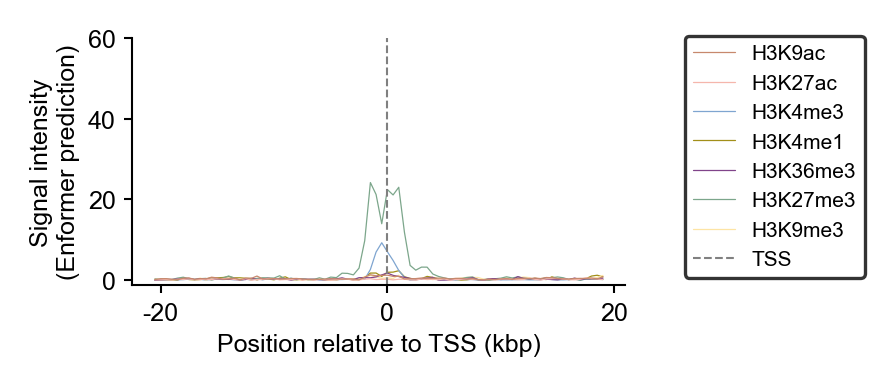

In [27]:
legend_order = ['H3K9ac','H3K27ac','H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3']
tracks = np.load('extra/datasets/processed/v1/E003/regions/ENSG00000143340.npy')[:7].T # (80, 7)
saved_path = None

plot_tracks(tracks,ylim=60,color_map=color_map,legend_order=legend_order,legend=True,saved_path=saved_path)

        simulation_id  bs_label_score  bf_label_score
4582  ENSGRND00004583        0.823371        0.968161


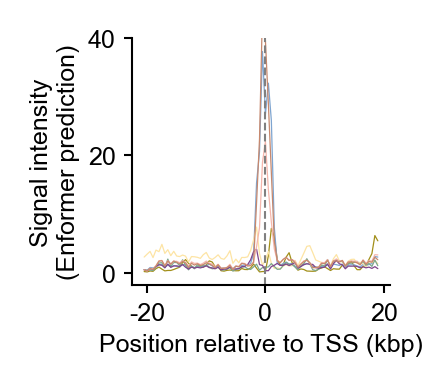

In [35]:
simulation_id = 'ENSGRND00004583'
print(df[df['simulation_id'] == simulation_id])
tracks = np.load(f'{npy_dir}/{simulation_id}.npy') # (80, 7)
figsize = (4/2.54, 3.5/2.54)
saved_path = None

plot_tracks(tracks,ylim=40,color_map=color_map,figsize=figsize,legend=False,saved_path=saved_path)


        simulation_id  bs_label_score  bf_label_score
2272  ENSGRND00002273        0.203355         0.71195


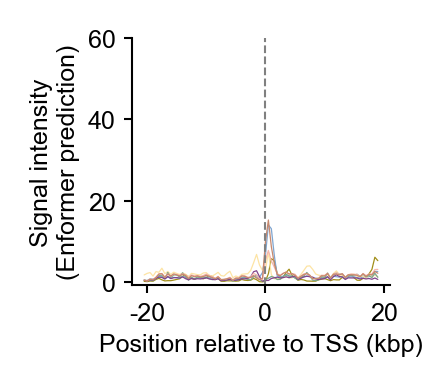

In [36]:

simulation_id = 'ENSGRND00002273'
print(df[df['simulation_id'] == simulation_id])
tracks = np.load(f'{npy_dir}/{simulation_id}.npy') # (80, 7)
figsize = (4/2.54, 3.5/2.54)
saved_path = None
plot_tracks(tracks,ylim=60,color_map=color_map,legend_order=legend_order,figsize=figsize,saved_path=saved_path)

        simulation_id  bs_label_score  bf_label_score
8221  ENSGRND00008222        0.611567        0.414545


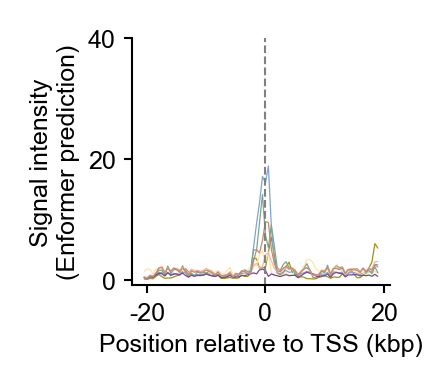

In [37]:
simulation_id = 'ENSGRND00008222'
print(df[df['simulation_id'] == simulation_id])
tracks = np.load(f'{npy_dir}/{simulation_id}.npy') # (80, 7)
figsize = (4/2.54, 3.5/2.54)
saved_path = None
plot_tracks(tracks,ylim=40,color_map=color_map,legend_order=legend_order,figsize=figsize,saved_path=saved_path)

        simulation_id  bs_label_score  bf_label_score     delta
1751  ENSGRND00001752        0.060681         0.08161  0.020929


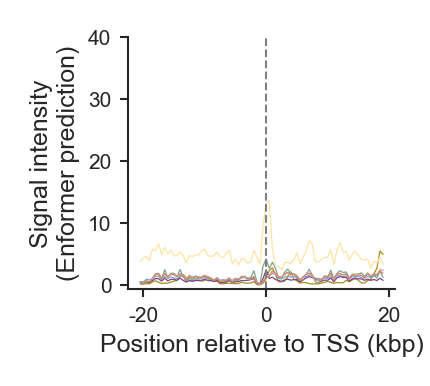

In [ ]:
simulation_id = 'ENSGRND00001752'
print(df[df['simulation_id'] == simulation_id])
tracks = np.load(f'{npy_dir}/{simulation_id}.npy') # (80, 7)
figsize = (4/2.54, 3.5/2.54)
saved_path = None
plot_tracks(tracks,ylim=40,color_map=color_map,legend_order=legend_order,figsize=figsize,saved_path=saved_path)

# 模拟组蛋白修饰分布分析

## 绘图

## TSS上下游1kbp 平均值

### PDIA4

In [43]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
gene_id = 'ENSG00000155660'
# 读入结果表
df = pd.read_csv(
    f'extra/results/{gene_id}_random_center_replaced_100k.csv'
)
npy_dir = f"extra/datasets/processed/v1/{gene_id}_random_center_replaced_100k/regions"

track_names = [
    'H3K4me1',
    'H3K4me3',
    'H3K9me3',
    'H3K27me3',
    'H3K36me3',
    'H3K27ac',
    'H3K9ac'
]

# 颜色设定：4 个 BF/BS 组合
group_colors = {
    "HIGH_BF_HIGH_BS": "#d7191c",  # 红
    "HIGH_BF_LOW_BS":  "#fdae61",  # 橙
    "LOW_BF_HIGH_BS":  "#2b83ba",  # 蓝
    "LOW_BF_LOW_BS":   "#abdda4",  # 绿
}

# 四种 BF/BS 组合（你之前已经有）
HIGH_BF_AND_HIGH_BS = df[(df['bf_label_score'] > 0.5) & (df['bs_label_score'] > 0.5)]
HIGH_BF_AND_LOW_BS  = df[(df['bf_label_score'] > 0.5) & (df['bs_label_score'] < 0.5)]
LOW_BF_AND_HIGH_BS  = df[(df['bf_label_score'] < 0.5) & (df['bs_label_score'] > 0.5)]
LOW_BF_AND_LOW_BS   = df[(df['bf_label_score'] < 0.5) & (df['bs_label_score'] < 0.5)]

groups = {
    "HIGH_BF_HIGH_BS": HIGH_BF_AND_HIGH_BS,
    "HIGH_BF_LOW_BS":  HIGH_BF_AND_LOW_BS,
    "LOW_BF_HIGH_BS":  LOW_BF_AND_HIGH_BS,
    "LOW_BF_LOW_BS":   LOW_BF_AND_LOW_BS,
}

# npy_dir = "extra/datasets/benchmark/Promoterformer/npy"

def bin_40kbp_matrix(matrix: np.ndarray, bin_size_bp: int = 500) -> np.ndarray:
    length, C = matrix.shape
    assert length == 40000, f"输入长度应为40kbp，这里是 {length}"
    n_bins = length // bin_size_bp  # 80
    binned = matrix.reshape(n_bins, bin_size_bp, C).mean(axis=1)
    return binned

# 收集 boxplot 用的数据
records = []  # list of dict

# 0-based index：取 bin 后 matrix 的第 39 和 40 行
tss_bin_indices = [39, 40]

for group_name, subdf in groups.items():
    sim_ids = subdf['simulation_id'].tolist()
    if len(sim_ids) == 0:
        print(f"[Warning] {group_name} 没有 simulation，跳过。")
        continue

    for sim_id in sim_ids:
        arr = np.load(os.path.join(npy_dir, f"{sim_id}.npy"))  # (40000,7) 或 (80,7)

        # 统一成 (80, 7)
        if arr.shape[0] == 40000:
            arr = bin_40kbp_matrix(arr)
        elif arr.shape[0] == 80:
            pass
        else:
            raise ValueError(f"Unexpected shape {arr.shape} for simulation_id={sim_id}")

        # 取 TSS 上下游 1000bp 对应的 bin（这里用第 39、40 行）
        local_region = arr[tss_bin_indices, :]         # (2, 7)
        local_mean = local_region.mean(axis=0)         # (7,)

        # 为每个 track 生成一条记录
        for t_idx, t_name in enumerate(track_names):
            records.append({
                "group": group_name,
                "track": t_name,
                "intensity": local_mean[t_idx],
                "simulation_id": sim_id,
            })

box_df = pd.DataFrame(records)
print("box_df shape:", box_df.shape)
box_df.head()

box_df shape: (70000, 4)


,group,track,intensity,simulation_id
0,HIGH_BF_HIGH_BS,H3K4me1,0.089353,ENSGRND00000003
1,HIGH_BF_HIGH_BS,H3K4me3,12.346020,ENSGRND00000003
2,HIGH_BF_HIGH_BS,H3K9me3,0.644349,ENSGRND00000003
3,HIGH_BF_HIGH_BS,H3K27me3,0.230275,ENSGRND00000003
4,HIGH_BF_HIGH_BS,H3K36me3,0.318303,ENSGRND00000003


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_36401/1748412779.py:61: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


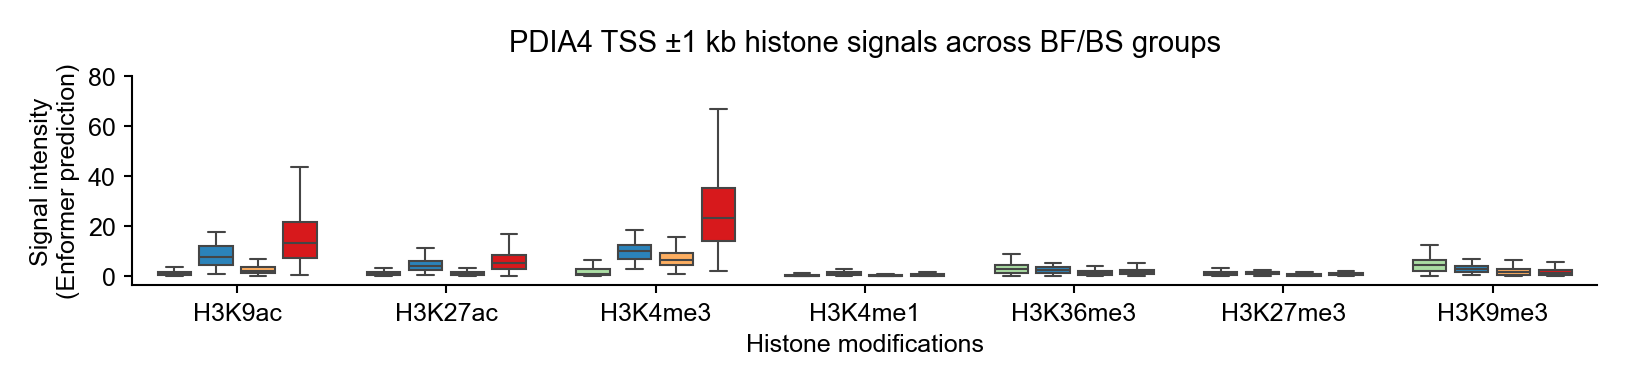

In [44]:
fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(14/2.54, 3.5/2.54))

order = pd.Index(["H3K9ac","H3K27ac","H3K4me3","H3K4me1","H3K36me3","H3K27me3","H3K9me3"],name='marks')

# hue_order = ["HIGH_BF_HIGH_BS", "HIGH_BF_LOW_BS", "LOW_BF_HIGH_BS", "LOW_BF_LOW_BS"]
hue_order = ["LOW_BF_LOW_BS", "LOW_BF_HIGH_BS", "HIGH_BF_LOW_BS", "HIGH_BF_HIGH_BS",]


# 颜色设定：4 个 BF/BS 组合
group_colors = {
    "HIGH_BF_HIGH_BS": "#d7191c",  # 红
    "HIGH_BF_LOW_BS":  "#fdae61",  # 橙
    "LOW_BF_HIGH_BS":  "#2b83ba",  # 蓝
    "LOW_BF_LOW_BS":   "#abdda4",  # 绿
}
ax = sns.boxplot(data=box_df, 
            x="track", 
            y="intensity", 
            order=order,
            hue_order=hue_order, 
            hue="group", 
            palette=group_colors,
            gap=0.2,
            width=0.8,
            saturation=1,
            fliersize=0, 
            linewidth=0.5,
            )


# 先拿到原 legend 信息
handles, labels = ax.get_legend_handles_labels()
ax.legend().remove()

# 将原标签映射为 “BF±, BS±”
label_map = {
    "HIGH_BF_HIGH_BS":"BF+, BS+",
    "HIGH_BF_LOW_BS": "BF+, BS−",
    "LOW_BF_HIGH_BS": "BF−, BS+",
    "LOW_BF_LOW_BS":  "BF−, BS−",
}
mapped_labels = [label_map[l] for l in labels]

ax.set_yticks([0, 20, 40, 60, 80])

ax.set_xlabel("Histone modifications", fontsize=6)
ax.set_ylabel("Signal intensity\n(Enformer prediction)", fontsize=6)
ax.set_title("PDIA4 TSS ±1 kb histone signals across BF/BS groups",
             fontsize=7, fontweight='regular')

fig.legend(
    handles,
    mapped_labels,
    title=None,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    ncol=1,
    edgecolor='none'
).remove()

plt.tight_layout()
plt.savefig(
    'extra/figures/v7/Supplementary_Figure11_PDIA4_boxplot.eps',
    format='eps',
    bbox_inches='tight',
    dpi=300
)
plt.show()


### FAM163A

In [45]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
gene_id = 'ENSG00000143340'
# 读入结果表
df = pd.read_csv(
    f'extra/results/{gene_id}_random_center_replaced_100k.csv'
)

npy_dir = f"extra/datasets/processed/v1/{gene_id}_random_center_replaced_100k/regions"


track_names = [
    'H3K4me1',
    'H3K4me3',
    'H3K9me3',
    'H3K27me3',
    'H3K36me3',
    'H3K27ac',
    'H3K9ac'
]

# 颜色设定：4 个 BF/BS 组合
group_colors = {
    "HIGH_BF_HIGH_BS": "#d7191c",  # 红
    "HIGH_BF_LOW_BS":  "#fdae61",  # 橙
    "LOW_BF_HIGH_BS":  "#2b83ba",  # 蓝
    "LOW_BF_LOW_BS":   "#abdda4",  # 绿
}

# 四种 BF/BS 组合（你之前已经有）
HIGH_BF_AND_HIGH_BS = df[(df['bf_label_score'] > 0.5) & (df['bs_label_score'] > 0.5)]
HIGH_BF_AND_LOW_BS  = df[(df['bf_label_score'] > 0.5) & (df['bs_label_score'] < 0.5)]
LOW_BF_AND_HIGH_BS  = df[(df['bf_label_score'] < 0.5) & (df['bs_label_score'] > 0.5)]
LOW_BF_AND_LOW_BS   = df[(df['bf_label_score'] < 0.5) & (df['bs_label_score'] < 0.5)]

groups = {
    "HIGH_BF_HIGH_BS": HIGH_BF_AND_HIGH_BS,
    "HIGH_BF_LOW_BS":  HIGH_BF_AND_LOW_BS,
    "LOW_BF_HIGH_BS":  LOW_BF_AND_HIGH_BS,
    "LOW_BF_LOW_BS":   LOW_BF_AND_LOW_BS,
}

# npy_dir = "extra/datasets/benchmark/Promoterformer/npy"

def bin_40kbp_matrix(matrix: np.ndarray, bin_size_bp: int = 500) -> np.ndarray:
    length, C = matrix.shape
    assert length == 40000, f"输入长度应为40kbp，这里是 {length}"
    n_bins = length // bin_size_bp  # 80
    binned = matrix.reshape(n_bins, bin_size_bp, C).mean(axis=1)
    return binned

# 收集 boxplot 用的数据
records = []  # list of dict

# 0-based index：取 bin 后 matrix 的第 39 和 40 行
tss_bin_indices = [39, 40]

for group_name, subdf in groups.items():
    sim_ids = subdf['simulation_id'].tolist()
    if len(sim_ids) == 0:
        print(f"[Warning] {group_name} 没有 simulation，跳过。")
        continue

    for sim_id in sim_ids:
        arr = np.load(os.path.join(npy_dir, f"{sim_id}.npy"))  # (40000,7) 或 (80,7)

        # 统一成 (80, 7)
        if arr.shape[0] == 40000:
            arr = bin_40kbp_matrix(arr)
        elif arr.shape[0] == 80:
            pass
        else:
            raise ValueError(f"Unexpected shape {arr.shape} for simulation_id={sim_id}")

        # 取 TSS 上下游 1000bp 对应的 bin（这里用第 39、40 行）
        local_region = arr[tss_bin_indices, :]         # (2, 7)
        local_mean = local_region.mean(axis=0)         # (7,)

        # 为每个 track 生成一条记录
        for t_idx, t_name in enumerate(track_names):
            records.append({
                "group": group_name,
                "track": t_name,
                "intensity": local_mean[t_idx],
                "simulation_id": sim_id,
            })

box_df = pd.DataFrame(records)
print("box_df shape:", box_df.shape)
box_df.head()

box_df shape: (70000, 4)


,group,track,intensity,simulation_id
0,HIGH_BF_HIGH_BS,H3K4me1,1.096173,ENSGRND00000010
1,HIGH_BF_HIGH_BS,H3K4me3,14.694822,ENSGRND00000010
2,HIGH_BF_HIGH_BS,H3K9me3,6.457022,ENSGRND00000010
3,HIGH_BF_HIGH_BS,H3K27me3,1.389785,ENSGRND00000010
4,HIGH_BF_HIGH_BS,H3K36me3,1.436544,ENSGRND00000010


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_36401/747627163.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


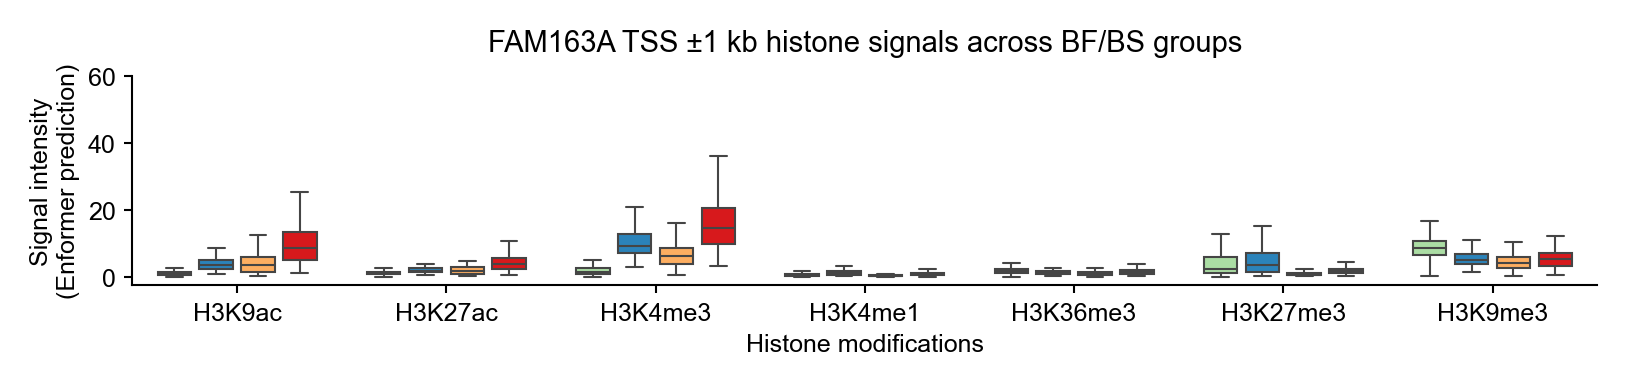

In [46]:
fig, ax = plt.subplots(1, 1, constrained_layout=True, figsize=(14/2.54, 3.5/2.54))

order = pd.Index(["H3K9ac","H3K27ac","H3K4me3","H3K4me1","H3K36me3","H3K27me3","H3K9me3"],name='marks')

hue_order = ["LOW_BF_LOW_BS", "LOW_BF_HIGH_BS", "HIGH_BF_LOW_BS", "HIGH_BF_HIGH_BS",]


# 颜色设定：4 个 BF/BS 组合
group_colors = {
    "HIGH_BF_HIGH_BS": "#d7191c",  # 红
    "HIGH_BF_LOW_BS":  "#fdae61",  # 橙
    "LOW_BF_HIGH_BS":  "#2b83ba",  # 蓝
    "LOW_BF_LOW_BS":   "#abdda4",  # 绿
}
ax = sns.boxplot(data=box_df, 
            x="track", 
            y="intensity", 
            order=order,
            hue_order=hue_order, 
            hue="group", 
            palette=group_colors,
            gap=0.2,
            width=0.8,
            saturation=1,
            fliersize=0, 
            linewidth=0.5,
            )


# 先拿到原 legend 信息
handles, labels = ax.get_legend_handles_labels()
ax.legend().remove()

# 将原标签映射为 “BF±, BS±”
label_map = {
    "HIGH_BF_HIGH_BS":"BF+, BS+",
    "HIGH_BF_LOW_BS": "BF+, BS−",
    "LOW_BF_HIGH_BS": "BF−, BS+",
    "LOW_BF_LOW_BS":  "BF−, BS−",
}
mapped_labels = [label_map[l] for l in labels]

ax.set_yticks([0, 20, 40, 60])
ax.set_xlabel("Histone modifications", fontsize=6)
ax.set_ylabel("Signal intensity\n(Enformer prediction)", fontsize=6)
ax.set_title("FAM163A TSS ±1 kb histone signals across BF/BS groups",
             fontsize=7, fontweight='regular')

fig.legend(
    handles,
    mapped_labels,
    title=None,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    ncol=1,
    edgecolor='none'
).remove()

plt.tight_layout()
plt.savefig(
    'extra/figures/v7/Supplementary_Figure11_FAM163A_boxplot.eps',
    format='eps',
    bbox_inches='tight',
    dpi=300
)
plt.show()


# Evaluation of mean and noise

In [ ]:
import numpy as np 
import torch
import pandas as pd
from tqdm import tqdm
from sklearn import metrics
from src.model.data import EnformerDataset
from src.model.net import  DeepBurst
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from src.model.constants import get_config


torch.autograd.set_detect_anomaly(True)

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]


#
# Training setup.
#
    
def evaluation(out:'torch.Tensor', label:'torch.Tensor'):
    score = out.softmax(axis=1)[:, 1]
    pred = out.argmax(axis=1)

    acc = metrics.accuracy_score(label, pred) * 100
    auc = metrics.roc_auc_score(label, score) * 100
    ap = metrics.average_precision_score(label, score) * 100
    return score, label, pred, acc, auc, ap

config_path = "configs/default.yaml"
config = get_config(config_path)


remove_marks = None
if remove_marks:
    config["remove_marks"] = [remove_marks]
else:
    config["remove_marks"] = []

feature_bin_kws = config['feature_bin_kws']
seed = config["seed"]

config['marked_bin_idxes'] = []
config['masked_marks'] = []

bsz = config["bsz"]
gamma = config["gamma"]

i_max = config["i_max"]
w_prom = config["w_prom"]
w_max = config["w_max"]

n_feats_p = config['promoter_feats_basic_nums'] - len(config["remove_marks"])
n_feats_pcres = config['pcres_feats_basic_nums'] 
d_emb = config["embed"]["d_model"]
embed_kws = config["embed"]
d_head = config["d_head"]
targets = ['mean_label']
# gene_id = "ENSG00000143340"
gene_id = "ENSG00000155660"
npy_dir = f"extra/datasets/processed/v1/{gene_id}_random_center_replaced_100k/regions"


binsizes = [500]

predictions = []
for eid in ["E003"]:
    for fold in [2]:
        print(f"eid:{eid},fold:{fold}")
        checkpoints = f"checkpoints/{eid}.{fold}.mean_para.model.pt"

        meta_path = f"extra/datasets/processed/v1/{gene_id}_random_center_replaced_100k/meta_data.csv"

        #
        # Setup end.
        #

        seed_everything(seed)
        meta = (
            pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
        )  # load and shuffle.

        # Split genes into two sets (train/val).
        genes = set(meta.gene_id.unique())
        n_genes = len(genes)
        print("Target genes:", len(genes))
        print(f"n_feats_p:{n_feats_p}")

        splits = {
            1: ['chr1', 'chr6', 'chr5', 'chr8', 'chr14', 'chrY'],
            2: ['chr7', 'chr10', 'chr11', 'chr12', 'chr15', 'chr21'],
            3: ['chr2', 'chr3', 'chr4', 'chr16', 'chr18', 'chr20'],
            4: ['chr9', 'chr13', 'chr17', 'chr19', 'chr22', 'chrX'],
        }

        chromosome_splits = {}
        for key, chroms in splits.items():
            for chrom in chroms:
                chromosome_splits[chrom] = key

        qs = [
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 1,axis=1)].gene_id.tolist(),
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 2,axis=1)].gene_id.tolist(),
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 3,axis=1)].gene_id.tolist(),
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 4,axis=1)].gene_id.tolist(),
        ]

        train_genes = (
            qs[(fold + 0) % 4] + qs[(fold + 1) % 4] + qs[(fold + 2) % 4]
        )
        val_genes = qs[(fold + 3) % 4]



        print(len(train_genes), len(val_genes))

        val_dataset = EnformerDataset(meta_path,val_genes,npy_dir, binsizes=[2000, 500, 100])
        val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=bsz)


        model = DeepBurst(
            n_feats_p,
            d_emb,
            d_head,
            embed_kws=embed_kws,
            binsizes=binsizes,
            seed=42,
            targets=targets,
        ).to(DEVICE)

        ckpt = torch.load(checkpoints,map_location=DEVICE)
        model.load_state_dict(ckpt["net"])


eid:E003,fold:2
Target genes: 10000
n_feats_p:7
0 10000


In [59]:
# gene_id = 'ENSG00000155660'
# gene_id = 'ENSG00000143340'
strand = '+' # '+', '-' Enformer 预测的所有序列都是正链的
results = []
for i in tqdm(range(1,10001)):
    if i < 10:
        i = f'0000{i}'
    elif i < 100:
        i = f'000{i}'
    elif i < 1000:
        i = f'00{i}'
    elif i < 10000:
        i = f'0{i}'
    else:
        i = str(i)
    data = np.load(f'{npy_dir}/ENSGRND000{i}.npy')
    # print(data.shape)

    if strand == '-':
        data = np.flip(data, axis=0)  # 翻转数据

    def bin_40kbp_matrix(matrix: np.ndarray, bin_size_bp: int = 500) -> np.ndarray:
        """
        将 40kbp × tracks 的矩阵，按 bin_size_bp 分箱平均。
        
        参数：
            matrix: np.ndarray, shape=(40000, C)，40kbp 范围的预测结果
            bin_size_bp: int, 每个 bin 的碱基长度，默认 500bp
        
        返回：
            np.ndarray, shape=(N_bins, C)，N_bins = 40000/bin_size_bp
        """
        length, C = matrix.shape
        assert length == 40000, f"输入长度应为40kbp，这里是 {length}"
        
        n_bins = length // bin_size_bp  # 80
        binned = matrix.reshape(n_bins, bin_size_bp, C).mean(axis=1)
        return binned

    binned = bin_40kbp_matrix(data)
    binned = torch.tensor(binned[np.newaxis, np.newaxis,:,:]).to(DEVICE) 
    model.eval()
    with torch.no_grad():
        out = model(binned)
        val_preds = {}

    for target, pred in zip(targets,torch.chunk(out, len(targets), axis=-1)):
                val_preds[target] = pred

    line = [f'ENSGRND000{i}']
    for target in targets:
        val_score = val_preds[target].softmax(axis=1)[:, 1]
        line.append(val_score.cpu().numpy().tolist()[0])

    results.append(line)

df = pd.DataFrame(results, columns=['id'] + targets)

df.columns = ['simulation_id'] + [f'{target}_score' for target in targets]
df.to_csv(f'extra/results/{gene_id}_random_center_replaced_100k_mean.csv', index=False)


100%|██████████| 10000/10000 [00:42<00:00, 233.74it/s]


In [ ]:
import numpy as np 
import torch
import pandas as pd
from tqdm import tqdm
from sklearn import metrics
from src.model.data import EnformerDataset
from src.model.net import  DeepBurst
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from src.model.constants import get_config

torch.autograd.set_detect_anomaly(True)

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]


#
# Training setup.
#
    
def evaluation(out:'torch.Tensor', label:'torch.Tensor'):
    score = out.softmax(axis=1)[:, 1]
    pred = out.argmax(axis=1)

    acc = metrics.accuracy_score(label, pred) * 100
    auc = metrics.roc_auc_score(label, score) * 100
    ap = metrics.average_precision_score(label, score) * 100
    return score, label, pred, acc, auc, ap

config_path = "configs/default.yaml"
config = get_config(config_path)


remove_marks = None
if remove_marks:
    config["remove_marks"] = [remove_marks]
else:
    config["remove_marks"] = []

feature_bin_kws = config['feature_bin_kws']
seed = config["seed"]

config['marked_bin_idxes'] = []
config['masked_marks'] = []

bsz = config["bsz"]
gamma = config["gamma"]

i_max = config["i_max"]
w_prom = config["w_prom"]
w_max = config["w_max"]

n_feats_p = config['promoter_feats_basic_nums'] - len(config["remove_marks"])
n_feats_pcres = config['pcres_feats_basic_nums'] 
d_emb = config["embed"]["d_model"]
embed_kws = config["embed"]
pairwise_interaction_kws = config["pairwise_interaction"]
regulation_kws = config["regulation"]
d_head = config["d_head"]
targets = ['cv_label']
# gene_id = "ENSG00000143340"
gene_id = "ENSG00000155660"
npy_dir = f"extra/datasets/processed/v1/{gene_id}_random_center_replaced_100k/regions"


binsizes = [500]

predictions = []
for eid in ["E003"]:
    for fold in [2]:
        print(f"eid:{eid},fold:{fold}")
        checkpoints = f"checkpoints/{eid}.{fold}.cv_para.model.pt"

        meta_path = f"extra/datasets/processed/v1/{gene_id}_random_center_replaced_100k/meta_data.csv"

        #
        # Setup end.
        #

        seed_everything(seed)
        meta = (
            pd.read_csv(meta_path).sample(frac=1, random_state=seed).reset_index(drop=True)
        )  # load and shuffle.

        # Split genes into two sets (train/val).
        genes = set(meta.gene_id.unique())
        n_genes = len(genes)
        print("Target genes:", len(genes))
        print(f"n_feats_p:{n_feats_p}")

        splits = {
            1: ['chr1', 'chr6', 'chr5', 'chr8', 'chr14', 'chrY'],
            2: ['chr7', 'chr10', 'chr11', 'chr12', 'chr15', 'chr21'],
            3: ['chr2', 'chr3', 'chr4', 'chr16', 'chr18', 'chr20'],
            4: ['chr9', 'chr13', 'chr17', 'chr19', 'chr22', 'chrX'],
        }

        chromosome_splits = {}
        for key, chroms in splits.items():
            for chrom in chroms:
                chromosome_splits[chrom] = key

        qs = [
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 1,axis=1)].gene_id.tolist(),
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 2,axis=1)].gene_id.tolist(),
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 3,axis=1)].gene_id.tolist(),
            meta[meta.apply(lambda row: chromosome_splits[row['chrom']] == 4,axis=1)].gene_id.tolist(),
        ]

        train_genes = (
            qs[(fold + 0) % 4] + qs[(fold + 1) % 4] + qs[(fold + 2) % 4]
        )
        val_genes = qs[(fold + 3) % 4]



        print(len(train_genes), len(val_genes))

        val_dataset = EnformerDataset(meta_path,val_genes,npy_dir, binsizes=[2000, 500, 100])
        val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=bsz)


        model = DeepBurst(
            n_feats_p,
            d_emb,
            d_head,
            embed_kws=embed_kws,
            binsizes=binsizes,
            seed=42,
            targets=targets,
        ).to(DEVICE)

        ckpt = torch.load(checkpoints,map_location=DEVICE)
        model.load_state_dict(ckpt["net"])


eid:E003,fold:2
Target genes: 10000
n_feats_p:7
0 10000


In [61]:
# gene_id = 'ENSG00000155660'
# gene_id = 'ENSG00000143340'
strand = '+' # '+', '-' Enformer 预测的所有序列都是正链的
results = []
for i in tqdm(range(1,10001)):
    if i < 10:
        i = f'0000{i}'
    elif i < 100:
        i = f'000{i}'
    elif i < 1000:
        i = f'00{i}'
    elif i < 10000:
        i = f'0{i}'
    else:
        i = str(i)
    data = np.load(f'{npy_dir}/ENSGRND000{i}.npy')
    # print(data.shape)

    if strand == '-':
        data = np.flip(data, axis=0)  # 翻转数据

    def bin_40kbp_matrix(matrix: np.ndarray, bin_size_bp: int = 500) -> np.ndarray:
        """
        将 40kbp × tracks 的矩阵，按 bin_size_bp 分箱平均。
        
        参数：
            matrix: np.ndarray, shape=(40000, C)，40kbp 范围的预测结果
            bin_size_bp: int, 每个 bin 的碱基长度，默认 500bp
        
        返回：
            np.ndarray, shape=(N_bins, C)，N_bins = 40000/bin_size_bp
        """
        length, C = matrix.shape
        assert length == 40000, f"输入长度应为40kbp，这里是 {length}"
        
        n_bins = length // bin_size_bp  # 80
        binned = matrix.reshape(n_bins, bin_size_bp, C).mean(axis=1)
        return binned

    binned = bin_40kbp_matrix(data)
    binned = torch.tensor(binned[np.newaxis, np.newaxis,:,:]).to(DEVICE) 
    model.eval()
    with torch.no_grad():
        out = model(binned)
        val_preds = {}

    for target, pred in zip(targets,torch.chunk(out, len(targets), axis=-1)):
                val_preds[target] = pred

    line = [f'ENSGRND000{i}']
    for target in targets:
        val_score = val_preds[target].softmax(axis=1)[:, 1]
        line.append(val_score.cpu().numpy().tolist()[0])

    results.append(line)

df = pd.DataFrame(results, columns=['id'] + targets)

df.columns = ['simulation_id'] + [f'{target}_score' for target in targets]
df.to_csv(f'extra/results/{gene_id}_random_center_replaced_100k_cv.csv', index=False)


100%|██████████| 10000/10000 [00:42<00:00, 237.77it/s]


## 区分BF+, BF- 等区间观察MEAN, Noise 变化

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_36401/15978794.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Expression", "Noise"])


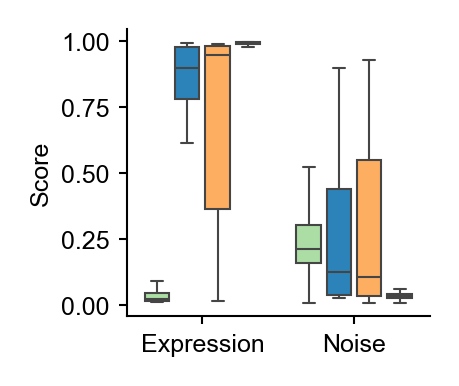

In [62]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

gene_id = 'ENSG00000155660'

mean_predictions = pd.read_csv(f'extra/results/{gene_id}_random_center_replaced_100k_mean.csv')
noise_predictions = pd.read_csv(f'extra/results/{gene_id}_random_center_replaced_100k_cv.csv')
bs_bf_predictions = pd.read_csv(f'extra/results/{gene_id}_random_center_replaced_100k.csv')
df = pd.merge(mean_predictions, noise_predictions, on='simulation_id')
df = pd.merge(df, bs_bf_predictions, on='simulation_id')


# 1. 先给每个样本打上 BF/BS 组合标签
def assign_group(row):
    if row['bf_label_score'] > 0.5 and row['bs_label_score'] > 0.5:
        return "HIGH_BF_HIGH_BS"
    elif row['bf_label_score'] > 0.5 and row['bs_label_score'] < 0.5:
        return "HIGH_BF_LOW_BS"
    elif row['bf_label_score'] < 0.5 and row['bs_label_score'] > 0.5:
        return "LOW_BF_HIGH_BS"
    else:
        return "LOW_BF_LOW_BS"

df["group"] = df.apply(assign_group, axis=1)

# 2. 配色
group_colors = {
    "HIGH_BF_HIGH_BS": "#d7191c",  # 红
    "HIGH_BF_LOW_BS":  "#fdae61",  # 橙
    "LOW_BF_HIGH_BS":  "#2b83ba",  # 蓝
    "LOW_BF_LOW_BS":   "#abdda4",  # 绿
}

# 3. 构造 boxplot 使用的长表：track = mean / cv
box_df = pd.DataFrame({
    "track":    np.repeat(["mean", "cv"], len(df)),
    "intensity": np.concatenate([
        df["mean_label_score"].values,
        df["cv_label_score"].values
    ]),
    "group":    np.tile(df["group"].values, 2)
})

# x 轴顺序 & hue 顺序
order = ["mean", "cv"]
hue_order = ["LOW_BF_LOW_BS", "LOW_BF_HIGH_BS",
             "HIGH_BF_LOW_BS", "HIGH_BF_HIGH_BS"]

# 4. 画图（按你给的风格参数）
plt.figure(figsize=(4/2.54, 3.5/2.54))
ax = sns.boxplot(
    data=box_df,
    x="track",
    y="intensity",
    order=order,
    hue="group",
    hue_order=hue_order,
    palette=group_colors,
    gap=0.2,
    width=0.8,
    saturation=1,
    fliersize=0,
    linewidth=0.5,
)

ax.set_xlabel("")                 # 看喜好，或改成 "Burst statistics"
ax.set_ylabel("Score")      # 可改成 "Mean / CV"
ax.set_xticklabels(["Expression", "Noise"])
# ax.legend().remove()
plt.legend(title="BF/BS category", bbox_to_anchor=(1.05, 1), loc="upper left", edgecolor='none', fontsize=6, title_fontsize=6).remove()
plt.tight_layout()

saved_path = 'extra/figures/v7/Supplementary_Figure11_PDIA4_mean_noise.eps'
plt.savefig(saved_path, format='eps', bbox_inches='tight')
plt.show()

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_36401/3074210128.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Expression", "Noise"])


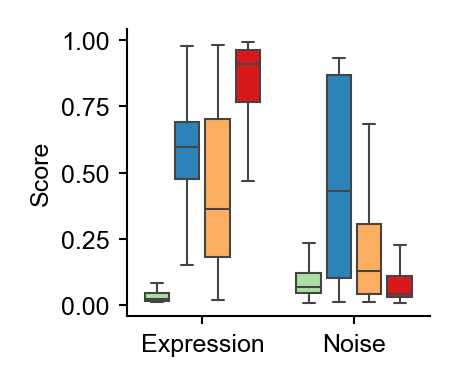

In [63]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

gene_id = 'ENSG00000143340'

mean_predictions = pd.read_csv(f'extra/results/{gene_id}_random_center_replaced_100k_mean.csv')
noise_predictions = pd.read_csv(f'extra/results/{gene_id}_random_center_replaced_100k_cv.csv')
bs_bf_predictions = pd.read_csv(f'extra/results/{gene_id}_random_center_replaced_100k.csv')
df = pd.merge(mean_predictions, noise_predictions, on='simulation_id')
df = pd.merge(df, bs_bf_predictions, on='simulation_id')


# 1. 先给每个样本打上 BF/BS 组合标签
def assign_group(row):
    if row['bf_label_score'] > 0.5 and row['bs_label_score'] > 0.5:
        return "HIGH_BF_HIGH_BS"
    elif row['bf_label_score'] > 0.5 and row['bs_label_score'] < 0.5:
        return "HIGH_BF_LOW_BS"
    elif row['bf_label_score'] < 0.5 and row['bs_label_score'] > 0.5:
        return "LOW_BF_HIGH_BS"
    else:
        return "LOW_BF_LOW_BS"

df["group"] = df.apply(assign_group, axis=1)

# 2. 配色
group_colors = {
    "HIGH_BF_HIGH_BS": "#d7191c",  # 红
    "HIGH_BF_LOW_BS":  "#fdae61",  # 橙
    "LOW_BF_HIGH_BS":  "#2b83ba",  # 蓝
    "LOW_BF_LOW_BS":   "#abdda4",  # 绿
}

# 3. 构造 boxplot 使用的长表：track = mean / cv
box_df = pd.DataFrame({
    "burst":    np.repeat(["mean", "cv"], len(df)),
    "score": np.concatenate([
        df["mean_label_score"].values,
        df["cv_label_score"].values
    ]),
    "group":    np.tile(df["group"].values, 2)
})

# x 轴顺序 & hue 顺序
order = ["mean", "cv"]
hue_order = ["LOW_BF_LOW_BS", "LOW_BF_HIGH_BS",
             "HIGH_BF_LOW_BS", "HIGH_BF_HIGH_BS"]

# 4. 画图（按你给的风格参数）
plt.figure(figsize=(4/2.54, 3.5/2.54))
ax = sns.boxplot(
    data=box_df,
    x="burst",
    y="score",
    order=order,
    hue="group",
    hue_order=hue_order,
    palette=group_colors,
    gap=0.2,
    width=0.8,
    saturation=1,
    fliersize=0,
    linewidth=0.5,
)

ax.set_xlabel("")                 # 看喜好，或改成 "Burst statistics"
ax.set_ylabel("Score")      # 可改成 "Mean / CV"
ax.set_xticklabels(["Expression", "Noise"])
# ax.legend().remove()
plt.legend(title="BF/BS category", bbox_to_anchor=(1.05, 1), loc="upper left", edgecolor='none', fontsize=6, title_fontsize=6).remove()
plt.tight_layout()
saved_path = 'extra/figures/v7/Supplementary_Figure11_FAM163A_mean_noise.eps'
plt.savefig(saved_path, format='eps', bbox_inches='tight')
plt.show()